In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv')

print(df['Code'].nunique())

1429


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv")

df_2022 = df[df["Year"] == 2022].copy()

df_2022["WC_TA"] = df_2022["X2"]
df_2022["RE_TA"] = df_2022["X8"]
df_2022["EBIT_TA"] = df_2022["X4"]
df_2022["S_TA"] = df_2022["X9"]

df_2022["MVE_TL"] = df_2022["X18"] / df_2022["X12"]

df_2022["Altman_Z"] = (
    1.2 * df_2022["WC_TA"]
    + 1.4 * df_2022["RE_TA"]
    + 3.3 * df_2022["EBIT_TA"]
    + 0.6 * df_2022["MVE_TL"]
    + 1.0 * df_2022["S_TA"]
)

df_2022["Predicted_Distress"] = np.where(
    df_2022["Altman_Z"] < 1.81, 1, 0
)

result = df_2022[
    ["Code", "Year", "Altman_Z", "Predicted_Distress", "Next_year_binary_distress_label"]
]

print(result.sort_values("Altman_Z"))

      Code  Year    Altman_Z  Predicted_Distress  \
12035  CAD  2022 -242.923848                   1   
11801  X77  2022  -42.755441                   1   
12454  APT  2022  -21.391576                   1   
12530  NOS  2022  -16.743049                   1   
12676  SCO  2022  -16.228202                   1   
...    ...   ...         ...                 ...   
12126  EIC  2022   23.690599                   0   
12403  EVG  2022   25.083450                   0   
12480  CVN  2022   27.730840                   0   
12190  VNB  2022   33.584715                   0   
12148  XPH  2022   34.088440                   0   

       Next_year_binary_distress_label  
12035                                1  
11801                                1  
12454                                1  
12530                                1  
12676                                1  
...                                ...  
12126                                0  
12403                                1  
12480 

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(
    result["Next_year_binary_distress_label"],
    result["Predicted_Distress"]
))

print(classification_report(
    result["Next_year_binary_distress_label"],
    result["Predicted_Distress"]
))


[[524 226]
 [ 97 197]]
              precision    recall  f1-score   support

           0       0.84      0.70      0.76       750
           1       0.47      0.67      0.55       294

    accuracy                           0.69      1044
   macro avg       0.65      0.68      0.66      1044
weighted avg       0.74      0.69      0.70      1044



In [8]:
df = pd.read_csv('/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv')

#print total distinct values in column 'Province'
print(df['Year'].unique())

[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]


Tương quan giữa SEN và các chỉ số tài chính:
X1     0.002271
X2    -0.005433
X3    -0.005649
X4    -0.037835
X5    -0.017149
X6    -0.068213
X7     0.010713
X8    -0.010219
X9    -0.061293
X10   -0.006766
X11    0.036557
X12   -0.000269
X13   -0.011168
X14    0.013741
X15    0.227023
X16    0.169587
X17   -0.039855
X18    0.002567
X19   -0.056854
Name: SEN, dtype: float64


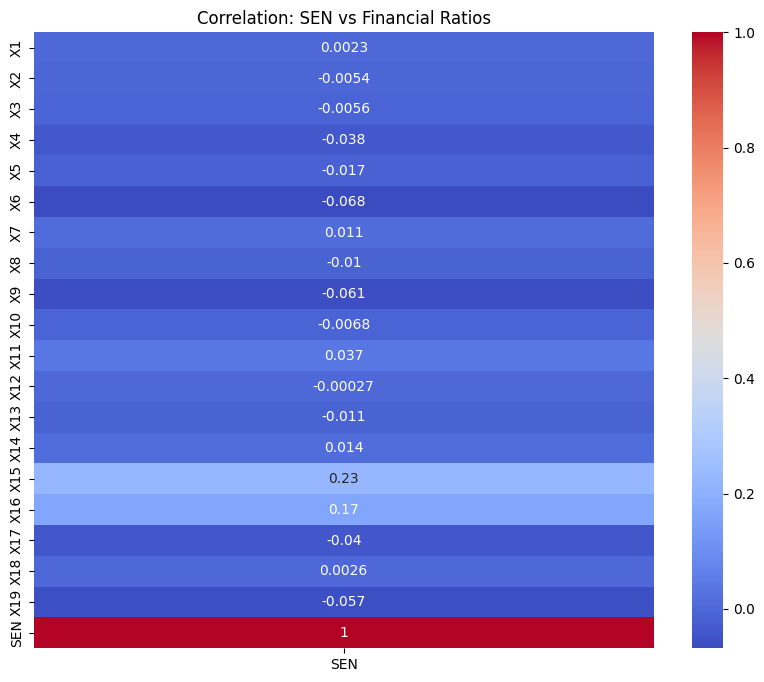

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv')

features = [f'X{i}' for i in range(1, 20)] + ['SEN']
corr_matrix = df[features].corr()

sen_correlation = corr_matrix['SEN'].drop('SEN')

print("Tương quan giữa SEN và các chỉ số tài chính:")
print(sen_correlation)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[['SEN']], annot=True, cmap='coolwarm')
plt.title("Correlation: SEN vs Financial Ratios")
plt.show()

In [ ]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 10.3 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_clean = df[features].dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = df_clean.columns
vif_data["VIF"] = [variance_inflation_factor(df_clean.values, i) for i in range(len(df_clean.columns))]

print(vif_data)

   Feature            VIF
0       X1       2.019064
1       X2      69.519290
2       X3       1.136269
3       X4       2.950685
4       X5       1.066593
5       X6       4.656869
6       X7       1.103112
7       X8      21.704915
8       X9       4.381935
9      X10  114097.654738
10     X11    4570.652748
11     X12  128417.029623
12     X13       1.011785
13     X14       2.168682
14     X15     156.162980
15     X16     128.456215
16     X17       6.826058
17     X18     151.820265
18     X19      42.676258
19     SEN       6.416851


In [11]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv('/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv')

train_df = df[df['Year'] <= 2021].copy()
test_df = df[df['Year'] == 2022].copy()

features = [f'X{i}' for i in range(1, 20)] + ['SEN']
target = 'Next_year_binary_distress_label'

X_train = train_df[features]
y_train = train_df[target]
X_train_with_const = sm.add_constant(X_train)

logit_model = sm.Logit(y_train, X_train_with_const)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.365467
         Iterations 10
                                  Logit Regression Results                                 
Dep. Variable:     Next_year_binary_distress_label   No. Observations:                11634
Model:                                       Logit   Df Residuals:                    11613
Method:                                        MLE   Df Model:                           20
Date:                             Sat, 02 May 2026   Pseudo R-squ.:                  0.3444
Time:                                     10:46:00   Log-Likelihood:                -4251.8
converged:                                    True   LL-Null:                       -6485.0
Covariance Type:                         nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
con

# EDA

## Train vs Test

## EDA

In [12]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv')

In [13]:
df.head()

,Code,Year,X1,X2,X3,X4,X5,X6,X7,X8,...,X12,X13,X14,X15,X16,X17,X18,X19,SEN,Next_year_binary_distress_label
0,SD2,2010,1.986111,0.393715,0.413592,0.064695,0.412698,0.144177,0.067961,0.049908,...,0.582255,0.633803,0.230769,6.293419,6.244167,0.151571,0.349353,0.685714,0.0,0
1,SD1,2010,1.093110,0.079239,0.185185,0.026941,0.294118,0.039620,0.062963,0.019017,...,0.855784,6.760000,0.005111,6.447306,5.598422,0.045959,0.134707,0.994444,0.0,0
2,BBC,2010,1.809783,0.196311,0.189086,0.059289,0.385321,0.276680,0.057107,0.054018,...,0.281950,0.785235,0.093093,6.632002,6.669498,0.528327,0.718050,0.859813,0.0,0
3,SD4,2010,0.937282,-0.035928,-0.056250,0.035928,0.596639,0.141717,0.056250,0.025948,...,0.762475,-7.611111,0.356877,6.216606,5.768321,0.441118,0.237525,0.751309,0.0,0
4,SCR,2010,2.259175,0.438298,2.979409,0.077571,0.027879,0.008034,0.527305,0.055578,...,0.711313,0.728365,0.462067,8.934982,7.018402,0.001185,0.288160,0.489354,0.0,0


In [14]:
print(df.shape[0])

12678


Số lượng từng lớp:
Next_year_binary_distress_label
0    9527
1    3151
Name: count, dtype: int64

Tỉ lệ phần trăm:
Next_year_binary_distress_label
0    75.145922
1    24.854078
Name: proportion, dtype: float64


/tmp/ipykernel_951/2528460091.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette="viridis")


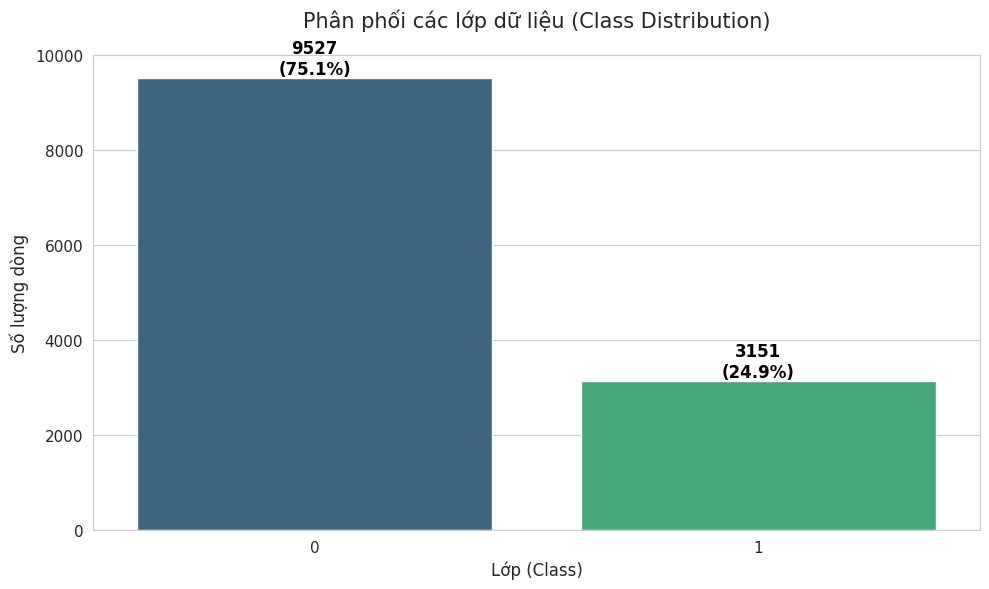

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv')

target_col = 'Next_year_binary_distress_label'
class_counts = df[target_col].value_counts()
class_percentages = df[target_col].value_counts(normalize=True) * 100

print("Số lượng từng lớp:")
print(class_counts)
print("\nTỉ lệ phần trăm:")
print(class_percentages)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.countplot(x=target_col, data=df, palette="viridis")

for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / len(df))
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(y)}\n({percentage})', (x, y),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')

plt.title('Phân phối các lớp dữ liệu (Class Distribution)', fontsize=15, pad=20)
plt.xlabel('Lớp (Class)', fontsize=12)
plt.ylabel('Số lượng dòng', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

/tmp/ipykernel_951/2388622730.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontweight='bold')


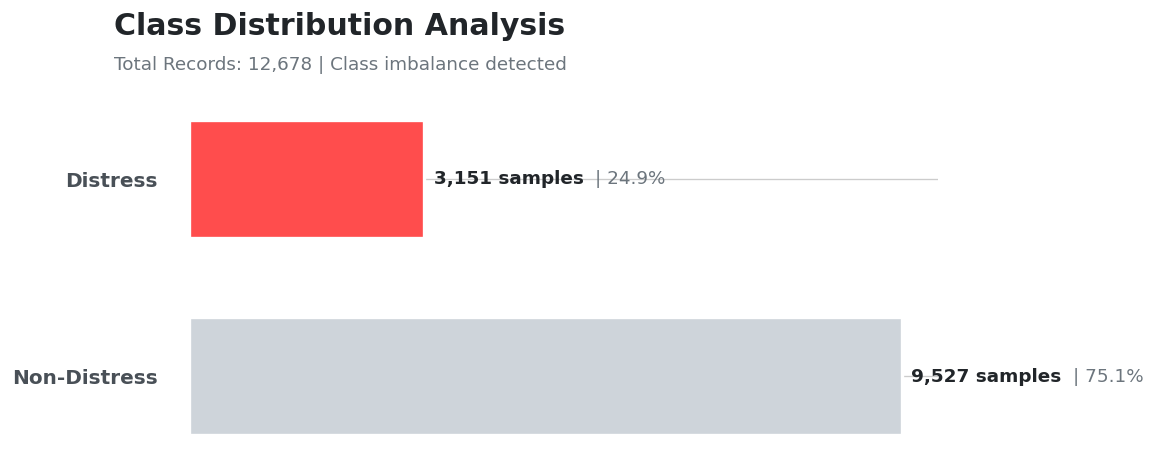

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

target_col = 'Next_year_binary_distress_label'
class_counts = df[target_col].value_counts().sort_index()
total = class_counts.sum()
labels = ['Non-Distress', 'Distress']

fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
fig.patch.set_facecolor('white')

colors = ['#ced4da', '#ff4d4d']
bars = ax.barh(labels, class_counts.values, color=colors, height=0.6, edgecolor='white', linewidth=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.get_xaxis().set_visible(False)

for i, bar in enumerate(bars):
    width = bar.get_width()
    percentage = f"{(width/total)*100:.1f}%"

    ax.text(width + (total*0.01), bar.get_y() + bar.get_height()/2,
            f'{int(width):,} samples',
            va='center', fontsize=11, fontweight='bold', color='#212529')

    ax.text(width + (total*0.18), bar.get_y() + bar.get_height()/2,
            f'| {percentage}',
            va='center', fontsize=11, color='#6c757d')

ax.tick_params(axis='y', labelsize=12, pad=15, colors='#495057')
ax.set_yticklabels(labels, fontweight='bold')

plt.text(-0.1, 1.2, 'Class Distribution Analysis',
         fontsize=18, fontweight='bold', color='#212529', transform=ax.transAxes)
plt.text(-0.1, 1.1, f'Total Records: {total:,} | Class imbalance detected',
         fontsize=11, color='#6c757d', transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

df_raw = pd.read_csv('/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv')


In [22]:
from scipy.stats import mannwhitneyu
import numpy as np

# Tách 2 nhóm
sen_sound = df_raw[df_raw[target] == 0]['SEN']
sen_distress = df_raw[df_raw[target] == 1]['SEN']

# Mann-Whitney U test
u_stat, p_value = mannwhitneyu(
    sen_sound,
    sen_distress,
    alternative='two-sided'
)

print(f"U-statistic: {u_stat}")
print(f"p-value: {p_value}")

U-statistic: 15758077.0
p-value: 2.5778582731022066e-05


In [23]:
n1 = len(sen_sound)
n2 = len(sen_distress)

rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(f"Rank-biserial correlation: {rank_biserial}")

Rank-biserial correlation: -0.049853367354243616


In [24]:
print("\n--- INTERPRETATION ---")

if p_value < 0.001:
    print("Reject H0: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm")
else:
    print("Fail to reject H0")

print(f"p-value = {p_value:.6f}")
print(f"Rank-biserial = {rank_biserial:.4f}")


--- INTERPRETATION ---
Reject H0: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm
p-value = 0.000026
Rank-biserial = -0.0499
